This notebook refits QUEST to random subsets of trials, and asks how the crowding vs. RSVP correlation changes with the noise ceiling.

Input (from `extract_trials_level_response.ipynb`):
- `tidy_both_sessions_trials_level_response.csv`
- `tidy_both_sessions_staircases_quest_params.csv`

Steps:
1. Rebuild each staircase's QUEST posterior and check that the posterior mean matches EasyEyes' `questMeanAtEndOfTrialsLoop`.
2. For each number of trials k, randomly pick k trials (without replacement) from every staircase and refit QUEST. Repeat `n_draws` times.
3. For each pair (k crowding, k RSVP) and each draw: reliability of each task (split-half + Spearman-Brown), noise ceiling = sqrt(rel_crowding * rel_rsvp), measured r, and corrected r = measured r / noise ceiling.
4. Plot correlation against the noise ceiling.

Results are saved to `subsample_corr_crowding_rsvp.csv`, so the plot can be remade without refitting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# settings
n_draws = 200
seed = 2026
quest_range = 5  # width (log units) of QUEST's grid of candidate thresholds; the jsQUEST default, validated below

# number of trials sampled from each staircase; np.inf = all trials
k_grid = {'crowding': [7, 8, 10, 12, 15, 18, 21, 25, 30, np.inf],  # letter trials (about 35 per staircase)
          'rsvp':     [6, 7, 9, 15, 21, 30, 40, 50, 60, np.inf]}  # single words (about 70 per staircase)

# staircases per participant, as columns of repeats.
# The order sets the split halves: first/last half = session 1 vs. session 2; odd/even = L8 vs. R8.
columns = {'crowding': ['crowding_R8_block1', 'crowding_L8_block1', 'crowding_R8_block2', 'crowding_L8_block2',
                        'crowding_R8_block3', 'crowding_L8_block3', 'crowding_R8_block4', 'crowding_L8_block4'],
           'rsvp': ['rsvp_foveal_block1', 'rsvp_foveal_block2']}

output_path = 'subsample_corr_crowding_rsvp.csv'

# Import data

In [3]:
trials = pd.read_csv('tidy_both_sessions_trials_level_response.csv')
staircases = pd.read_csv('tidy_both_sessions_staircases_quest_params.csv')
staircases = staircases[staircases['nTrials'] > 0].reset_index(drop=True)

# QUEST
Same computation as QuestCreate, QuestUpdate and QuestMean (Watson & Pelli, 1983, *Perception & Psychophysics* 33:113-120; jsQUEST in EasyEyes):
- Prior: Gaussian over log threshold, mean tGuess, SD tGuessSd, on a grid with step `grain`.
- Psychometric function (Weibull): P(correct) = delta*gamma + (1-delta) * (1 - (1-gamma) * exp(-10^(beta * (level - threshold + xThreshold)))). xThreshold makes P(correct) = pThreshold when level = threshold.
- Estimate: posterior mean.

Because the posterior is the prior times the likelihood of each response, the order of trials does not matter, so a random subset can be fit directly.

In [4]:
def quest_grid(st, quest_range=5):
    """Candidate thresholds (log units) and log prior, as in QuestCreate."""
    dim = int(2 * np.ceil(quest_range / st.grain / 2))
    x = np.arange(-dim // 2, dim // 2 + 1) * st.grain
    return st.tGuess + x, -0.5 * (x / st.tGuessSd) ** 2, dim


def quest_loglik(st, levels, responses, quest_range=5):
    """
    Log likelihood of each response (rows) at each candidate threshold (columns).
    As in QuestUpdate, the level is rounded to the grid, and level - threshold is limited to the table range.
    """
    t, _, dim = quest_grid(st, quest_range)
    xThreshold = np.log10(-np.log((1 - (st.pThreshold - st.delta * st.gamma) / (1 - st.delta)) / (1 - st.gamma))) / st.beta
    levels = st.tGuess + st.grain * np.round((np.asarray(levels) - st.tGuess) / st.grain)
    d = np.clip(levels[:, None] - t[None, :], -dim * st.grain, dim * st.grain)
    p = st.delta * st.gamma + (1 - st.delta) * (1 - (1 - st.gamma) * np.exp(-10 ** (st.beta * (d + xThreshold))))
    return np.where(np.asarray(responses)[:, None] == 1, np.log(p), np.log(1 - p))


def quest_mean(t, log_posterior):
    """Posterior mean (QuestMean). log_posterior can be 1-D, or 2-D with one row per draw."""
    w = np.exp(log_posterior - log_posterior.max(axis=-1, keepdims=True))
    return (w * t).sum(axis=-1) / w.sum(axis=-1)

In [5]:
# build the likelihood table of every staircase once
trials_by_staircase = dict(tuple(trials.groupby(['prolificID', 'conditionName'])))
quest_tables = {}
for st in staircases.itertuples():
    g = trials_by_staircase[(st.prolificID, st.conditionName)]
    t, log_prior, _ = quest_grid(st, quest_range)
    quest_tables[(st.prolificID, st.conditionName)] = (t, log_prior, quest_loglik(st, g['level'], g['response'], quest_range))

In [6]:
# validation: refit with all trials and compare with EasyEyes' final QUEST mean
staircases['refit_all_trials'] = [quest_mean(t, log_prior + L.sum(axis=0))
                                  for t, log_prior, L in (quest_tables[key] for key in zip(staircases['prolificID'], staircases['conditionName']))]
refit_error = (staircases['refit_all_trials'] - staircases['questMeanAtEnd']).abs()

print('Largest |refit - questMeanAtEndOfTrialsLoop| (log units):')
print(refit_error.groupby(staircases['taskName']).max())
assert refit_error.max() < 1e-3, 'Fatal: QUEST refit does not match EasyEyes'

Largest |refit - questMeanAtEndOfTrialsLoop| (log units):
taskName
acuity      0.000002
crowding    0.000002
rsvp        0.000010
dtype: float64


# Data cleaning

In [7]:
# exclude participants, per task
with open('exclude_dict.json', 'r') as f:
    exclude_dict = json.load(f)

for task, exclude_ids in exclude_dict.items():
    staircases = staircases[~((staircases['taskName'] == task) & (staircases['prolificID'].isin(exclude_ids)))]

# keep participants who have every crowding and RSVP staircase, so the sample is the same for every k
all_columns = columns['crowding'] + columns['rsvp']
n_staircases = staircases[staircases['conditionName'].isin(all_columns)].groupby('prolificID')['conditionName'].nunique()
subjects = np.sort(n_staircases[n_staircases == len(all_columns)].index.to_numpy())

print(f'Number of participants with all {len(all_columns)} crowding and RSVP staircases: {len(subjects)}')

Number of participants with all 10 crowding and RSVP staircases: 93


# Subsample trials and refit

In [8]:
def subsample_thresholds(task, rng):
    """
    Refit QUEST to k randomly chosen trials (without replacement) from each staircase.
    Within a draw, the subsets are nested across k (the trials for k=5 are among the trials for k=8).
    Returns
      thresholds: shape (len(k_grid[task]), n_draws, n_subjects, n_columns)
      n_short: for each k, the number of staircases with fewer than k trials (all of their trials were used)
    """
    ks = k_grid[task]
    thresholds = np.full((len(ks), n_draws, len(subjects), len(columns[task])), np.nan)
    n_short = np.zeros(len(ks), dtype=int)

    for s, prolificID in enumerate(subjects):
        for c, condition_name in enumerate(columns[task]):
            t, log_prior, L = quest_tables[(prolificID, condition_name)]
            n = L.shape[0]
            trial_rank = rng.random((n_draws, n)).argsort(axis=1).argsort(axis=1)  # random order of trials, per draw
            for i, k in enumerate(ks):
                chosen = (trial_rank < k).astype(float)
                thresholds[i, :, s, c] = quest_mean(t, log_prior + chosen @ L)
                n_short[i] += np.isfinite(k) and n < k

    return thresholds, n_short

In [9]:
rng = np.random.default_rng(seed)
thresholds = {}
for task in ['crowding', 'rsvp']:
    thresholds[task], n_short = subsample_thresholds(task, rng)
    print(f'{task}: staircases with fewer than k trials, per k {k_grid[task]}: {n_short.tolist()}')

# RSVP: log10(sec per word) -> log10(words per min), as in extract_thresholds_per_trial
thresholds['rsvp'] = np.log10(60) - thresholds['rsvp']

crowding: staircases with fewer than k trials, per k [7, 8, 10, 12, 15, 18, 21, 25, 30, inf]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


rsvp: staircases with fewer than k trials, per k [6, 7, 9, 15, 21, 30, 40, 50, 60, inf]: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# Reliability and correlation

In [10]:
def pearson_r(a, b):
    """Pearson r along the last axis."""
    a = a - a.mean(axis=-1, keepdims=True)
    b = b - b.mean(axis=-1, keepdims=True)
    return (a * b).sum(axis=-1) / np.sqrt((a * a).sum(axis=-1) * (b * b).sum(axis=-1))


def split_half_reliability(X):
    """
    Same method as summarize_task in analysis_from_tidy_per_trial:
    split-half r for first/last half and for odd/even columns, geometric mean, then Spearman-Brown.
    X has shape (..., n_subjects, n_columns). Returns reliability, r_FL and r_OE, each with shape (...).
    Unlike summarize_task, reliability is NaN where either split-half r is negative
    (reliability can't be estimated there); those draws are left out of later analyses.
    """
    n = X.shape[-1]
    r_FL = pearson_r(X[..., :n // 2].mean(axis=-1), X[..., n // 2:].mean(axis=-1))
    r_OE = pearson_r(X[..., 1::2].mean(axis=-1), X[..., 0::2].mean(axis=-1))

    negative = (r_FL < 0) | (r_OE < 0)
    r_i = np.clip(np.sqrt(np.where(negative, np.nan, r_FL * r_OE)), 0.0, 0.999999)
    return 2 * r_i / (1 + r_i), r_FL, r_OE

In [11]:
reliability = {}
negative_splits = []
for task in ['crowding', 'rsvp']:
    reliability[task], r_FL, r_OE = split_half_reliability(thresholds[task])  # each shape (n_k, n_draws)

    # record every (k, draw) where a split-half r was negative
    i_k, i_draw = np.where((r_FL < 0) | (r_OE < 0))
    negative_splits.append(pd.DataFrame({'taskName': task,
                                         'k': np.array(k_grid[task])[i_k],
                                         'draw': i_draw,
                                         'r_FL': r_FL[i_k, i_draw],
                                         'r_OE': r_OE[i_k, i_draw],
                                         'reliability': reliability[task][i_k, i_draw]}))  # NaN: left out
negative_splits = pd.concat(negative_splits, ignore_index=True)
negative_splits.to_csv('negative_split_half_r_crowding_rsvp.csv', index=False)

print('Number of draws with a negative split-half r, per task and k:')
print(negative_splits.groupby(['taskName', 'k']).size().to_string())
print('\nAll draws with a negative split-half r:')
print(negative_splits.round(3).to_string(index=False))

# per participant: mean over all staircases of a task
x = thresholds['crowding'].mean(axis=-1)  # (n_k crowding, n_draws, n_subjects)
y = thresholds['rsvp'].mean(axis=-1)      # (n_k rsvp, n_draws, n_subjects)

zx = (x - x.mean(axis=-1, keepdims=True)) / x.std(axis=-1, keepdims=True)
zy = (y - y.mean(axis=-1, keepdims=True)) / y.std(axis=-1, keepdims=True)
r_measured = np.einsum('ids,jds->ijd', zx, zy) / len(subjects)  # (n_k crowding, n_k rsvp, n_draws)

r_ceiling = np.sqrt(reliability['crowding'][:, None, :] * reliability['rsvp'][None, :, :])
r_corrected = r_measured / r_ceiling

# leave out draws where either task's reliability is NaN, so measured and corrected r use the same draws
r_measured = np.where(np.isnan(r_ceiling), np.nan, r_measured)

Number of draws with a negative split-half r, per task and k:
Series([], )

All draws with a negative split-half r:
Empty DataFrame
Columns: [taskName, k, draw, r_FL, r_OE, reliability]
Index: []


In [12]:
# long form: one row per (k crowding, k rsvp, draw)
i, j, d = np.meshgrid(np.arange(len(k_grid['crowding'])), np.arange(len(k_grid['rsvp'])), np.arange(n_draws), indexing='ij')
results = pd.DataFrame({'k_crowding': np.array(k_grid['crowding'])[i.ravel()],
                        'k_rsvp': np.array(k_grid['rsvp'])[j.ravel()],
                        'draw': d.ravel(),
                        'rel_crowding': reliability['crowding'][i.ravel(), d.ravel()],
                        'rel_rsvp': reliability['rsvp'][j.ravel(), d.ravel()],
                        'r_ceiling': r_ceiling.ravel(),
                        'r_measured': r_measured.ravel(),
                        'r_corrected': r_corrected.ravel()})
results['n_subjects'] = len(subjects)
results.to_csv(output_path, index=False)

In [13]:
def summarize_draws(results):
    """
    One row per (k crowding, k rsvp): median and 25th/75th percentiles across draws.
    Medians are used because corrected r = r / ceiling has extreme values when a draw's ceiling is near 0.
    """
    stats_cols = ['rel_crowding', 'rel_rsvp', 'r_ceiling', 'r_measured', 'r_corrected']
    g = results.groupby(['k_crowding', 'k_rsvp'])[stats_cols]
    summary = g.median()
    for q in [0.25, 0.75]:
        summary = summary.join(g.quantile(q)[['r_measured', 'r_corrected']].add_suffix(f'_q{int(q * 100)}'))
    summary['n_draws_used'] = results.groupby(['k_crowding', 'k_rsvp'])['r_corrected'].count()  # draws with NaN reliability are left out
    return summary.reset_index()


display(summarize_draws(results).round(3))

,k_crowding,k_rsvp,rel_crowding,rel_rsvp,r_ceiling,r_measured,r_corrected,r_measured_q25,r_corrected_q25,r_measured_q75,r_corrected_q75,n_draws_used
0,7.0,6.0,0.506,0.441,0.466,-0.203,-0.443,-0.261,-0.588,-0.138,-0.290,200
1,7.0,7.0,0.506,0.528,0.504,-0.216,-0.435,-0.265,-0.562,-0.170,-0.320,200
2,7.0,9.0,0.506,0.645,0.566,-0.232,-0.423,-0.282,-0.513,-0.193,-0.342,200
3,7.0,15.0,0.506,0.794,0.630,-0.261,-0.414,-0.307,-0.492,-0.221,-0.349,200
4,7.0,21.0,0.506,0.851,0.654,-0.276,-0.431,-0.315,-0.495,-0.228,-0.352,200
...,...,...,...,...,...,...,...,...,...,...,...,...
95,inf,30.0,0.877,0.887,0.882,-0.392,-0.445,-0.405,-0.459,-0.378,-0.428,200
96,inf,40.0,0.877,0.905,0.891,-0.401,-0.449,-0.411,-0.462,-0.389,-0.438,200
97,inf,50.0,0.877,0.913,0.895,-0.404,-0.451,-0.411,-0.459,-0.396,-0.443,200
98,inf,60.0,0.877,0.919,0.898,-0.405,-0.451,-0.410,-0.457,-0.401,-0.447,200


# Visualization
The y axis is correlation strength, -r (crowding distance and RSVP reading speed are negatively correlated).
Each dot is one (k crowding, k RSVP) pair: the median across draws.
The pairs are grouped into equal-width bins of the noise ceiling. In each bin, the line is the mean of the dots, and the shaded area spans the mean 25th to the mean 75th percentile across draws.

In [14]:
def plot_corr_vs_ceiling(summary, n_bins=8, title='Crowding vs. RSVP reading speed'):

    # (label, color of the band, color of the dots and line), as in plot_corr_vs_ceiling_draws
    series = {'r_measured': ('Measured r', '#dcc5fa', '#a866ff'),
              'r_corrected': ('Corrected r', '#fcefac', '#fcc80d')}
    bins = np.linspace(summary['r_ceiling'].min(), summary['r_ceiling'].max(), n_bins + 1)
    ceiling_bin = pd.cut(summary['r_ceiling'], bins, include_lowest=True)

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r; the 75th percentile of r becomes the lower edge of -r
        strength = summary.assign(y=-summary[col], lo=-summary[f'{col}_q75'], hi=-summary[f'{col}_q25'])
        binned = strength.groupby(ceiling_bin, observed=True).agg(x=('r_ceiling', 'mean'), y=('y', 'mean'),
                                                                 lo=('lo', 'mean'), hi=('hi', 'mean'))
        ax.fill_between(binned['x'], binned['lo'], binned['hi'], color=light_color, alpha=0.5,lw=0)
        ax.scatter(strength['r_ceiling'], strength['y'], s=25, color=dark_color, alpha=0.5, lw=0)
        ax.plot(binned['x'], binned['y'], color=dark_color, lw=2, label=label)

    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

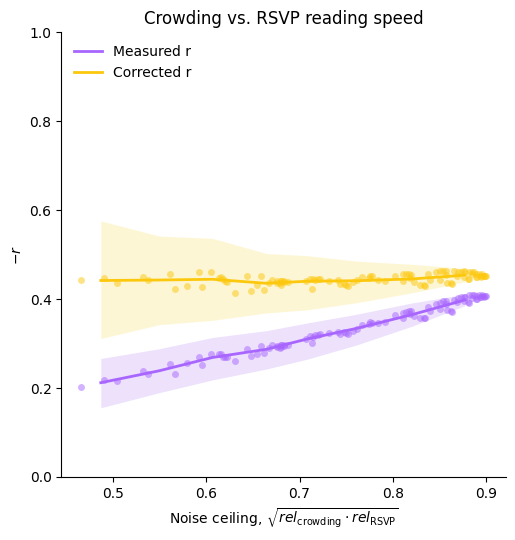

In [15]:
plot_corr_vs_ceiling(summarize_draws(pd.read_csv(output_path)))

## Version 2: one line per draw
Each light line is one draw: its 100 (k crowding, k RSVP) pairs, at their exact noise ceiling and correlation, joined in order of the noise ceiling (no binning). Together, the light lines show the spread across draws.
The dark line is one example draw (`example_draw`), not the median: it shows what a single experiment could look like.

In [16]:
from matplotlib.collections import LineCollection


def plot_corr_vs_ceiling_draws(results, example_draw=0, title='Crowding vs. RSVP reading speed'):

    # (label, color of the light per-draw lines, color of the example draw)
    series = {'r_measured': ('Measured r', '#dcc5fa', '#a866ff'),
              'r_corrected': ('Corrected r', '#fcefac', '#fcc80d')}

    # one line per draw: all grid pairs, sorted by that draw's noise ceiling
    results = results.dropna(subset=['r_ceiling']).sort_values(['draw', 'r_ceiling'])
    draws = dict(tuple(results.groupby('draw')))

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r
        lines = [np.column_stack([d['r_ceiling'], -d[col]]) for d in draws.values()]
        ax.add_collection(LineCollection(lines, colors=light_color, linewidths=1.5, alpha=0.15, zorder=1))
        example = draws[example_draw]
        ax.plot(example['r_ceiling'], -example[col], color=dark_color, lw=1.5, label=f'{label}, one draw', zorder=3)

    ax.set_xlim(results['r_ceiling'].min() - 0.02, results['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

Example draw: 76 (noise ceiling from 0.30 to 0.90)


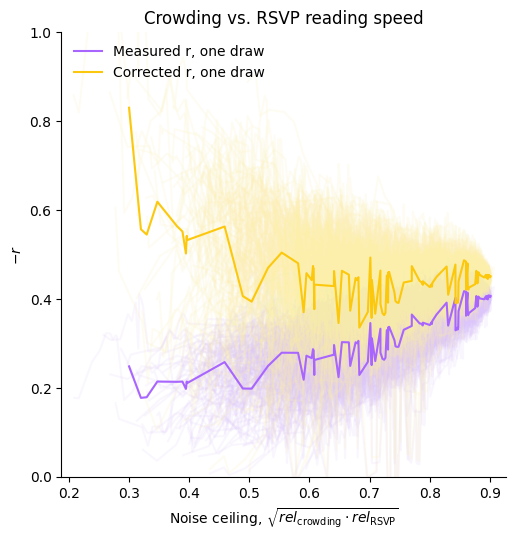

In [17]:
results = pd.read_csv(output_path)

# example draw: the one whose lowest noise ceiling is closest to 0.3, so its line spans about 0.3 to 0.9
lowest_ceiling = results.groupby('draw')['r_ceiling'].min()
example_draw = (lowest_ceiling - 0.3).abs().idxmin()
print(f'Example draw: {example_draw} (noise ceiling from {lowest_ceiling[example_draw]:.2f} to 0.90)')

plot_corr_vs_ceiling_draws(results, example_draw=example_draw)

## Version 3: 95% band across draws
Same as version 2, but the per-draw lines are replaced by a filled area. All draws' (noise ceiling, correlation) points are pooled and grouped into `n_bins` equal-width bins of the noise ceiling. In each bin, the area spans the 2.5th to 97.5th percentile of -r across draws, so it holds the middle 95% of draws. Bins with fewer than `min_points` points are left out.
This band shows the spread from choosing different trial subsets; it is not a confidence interval for the true correlation.
The dark line is the same example draw as in version 2.

In [60]:
def plot_corr_vs_ceiling_band(results, example_draw=0, n_bins=15, min_points=20, title='Crowding vs. RSVP reading speed'):

    # (label, color of the 95% band, color of the example draw), as in plot_corr_vs_ceiling_draws
    series = {'r_measured': ('Measured r', '#dcc5fa', '#a866ff'),
              'r_corrected': ('Corrected r', '#fcefac', '#fcc80d')}

    results = results.dropna(subset=['r_ceiling'])
    bins = np.linspace(results['r_ceiling'].min(), results['r_ceiling'].max(), n_bins + 1)
    ceiling_bin = pd.cut(results['r_ceiling'], bins, include_lowest=True)
    example = results[results['draw'] == example_draw].sort_values('r_ceiling')

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for col, (label, light_color, dark_color) in series.items():
        # plot correlation strength, -r: 2.5th to 97.5th percentile across draws, per bin of the noise ceiling
        # plot correlation strength, -r: 16th to 84th percentile across draws, per bin of the noise ceiling

        strength = -results[col]
        band = (strength.groupby(ceiling_bin, observed=True)
                .agg(lo=lambda s: s.quantile(0.16), hi=lambda s: s.quantile(0.84), n='count'))
        band['x'] = results['r_ceiling'].groupby(ceiling_bin, observed=True).mean()
        band = band[band['n'] >= min_points]
        ax.fill_between(band['x'], band['lo'], band['hi'], color=light_color, alpha=0.5, lw=0, zorder=1)
        ax.plot(example['r_ceiling'], -example[col], color=dark_color, lw=1.5, label=f'{label}, one draw', zorder=3)

    ax.set_xlim(results['r_ceiling'].min() - 0.02, results['r_ceiling'].max() + 0.02)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Noise ceiling, $\sqrt{\mathit{rel}_{\mathrm{crowding}} \cdot \mathit{rel}_{\mathrm{RSVP}}}$')
    ax.set_ylabel('$-r$')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, loc='upper left')
    plt.tight_layout()
    plt.show()

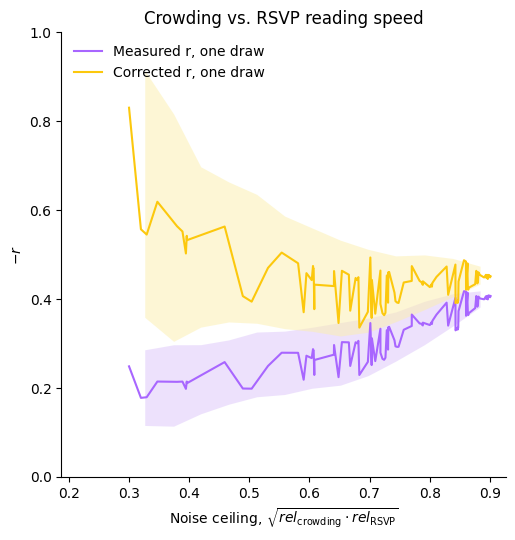

In [61]:
plot_corr_vs_ceiling_band(results, example_draw=example_draw)